# **Validation de données**
Ce dataset contient 6647 lignes et 24 colonnes.
La structure du jeu de données a été examinée et la colonne temporelle date ont été converties au format datetime afin de permettre une analyse chronologique fiable, et les variables quantitatives telles que NumArticles, AvgTone et GoldsteinScale ont été converties en types numériques
Certaines variables présentent des valeurs manquantes notamment Actor2Name et Actor2CountryCode. Ces absences sont fréquentes dans les données issues de GDELT. Et plutôt que de supprimer ces observations, les valeurs manquantes ont été remplacées par la modalité "Inconnu" afin de conserver un maximum d’information tout en explicitant l’incertitude.


In [ ]:
# Manipulation de données
from pathlib import Path
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

# Options d'affichage
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

: 

In [ ]:
data_path = project_root / "data/processed/gdelt_benin_clean.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Fichier introuvable: {data_path}")

df_events_benin = pd.read_csv(data_path, sep=",")

print(df_events_benin.columns)
print("Nombre de lignes :", df_events_benin.shape)
df_events_benin.info()

Index(['Actor1Name', 'Actor1CountryCode', 'Actor2Name', 'Actor2CountryCode',
       'EventCode', 'EventBaseCode', 'EventRootCode', 'GoldsteinScale',
       'NumArticles', 'AvgTone', 'ActionGeo_FullName', 'ActionGeo_CountryCode',
       'ActionGeo_Lat', 'ActionGeo_Long', 'SOURCEURL', 'date', 'annee', 'mois',
       'mois_label', 'semaine', 'event_label', 'sentiment'],
      dtype='object')
Nombre de lignes : (6647, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6647 entries, 0 to 6646
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Actor1Name             6647 non-null   object 
 1   Actor1CountryCode      6647 non-null   object 
 2   Actor2Name             6647 non-null   object 
 3   Actor2CountryCode      6647 non-null   object 
 4   EventCode              6647 non-null   int64  
 5   EventBaseCode          6647 non-null   int64  
 6   EventRootCode          6647 non-null   int64  
 7 

In [17]:
# Copie de sécurité
df_clean = df_events_benin.copy()

#Suppression de colonnes non pertinentes
df_clean = df_clean.drop(columns=['annee', 'mois', 'mois_label', 'semaine'])

# Types
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')
df_clean['NumArticles'] = pd.to_numeric(df_clean['NumArticles'], errors='coerce')
df_clean['AvgTone'] = pd.to_numeric(df_clean['AvgTone'], errors='coerce')
df_clean['GoldsteinScale'] = pd.to_numeric(df_clean['GoldsteinScale'], errors='coerce')

# Gestion des valeurs manquantes
df_clean['Actor2Name'] = df_clean['Actor2Name'].fillna('Inconnu')
df_clean['Actor2CountryCode'] = df_clean['Actor2CountryCode'].fillna('Inconnu')
df_clean['event_label'] = df_clean['event_label'].fillna('Inconnu')

# Supprimer doublons
df_clean = df_clean.drop_duplicates()

# Création variables utiles
df_clean['is_high_media'] = (df_clean['NumArticles'] > df_clean['NumArticles'].median()).astype(int)

# Implication internationale
df_clean['is_international'] = (df_clean['Actor2CountryCode'] != 'BEN').astype(int)

print(df_clean.shape)

(6647, 20)


In [18]:
df_clean.isnull().values.any()

np.False_

### Analyse exploratoire des données (EDA)

L’analyse exploratoire des données vise à comprendre la structure, les tendances et les dynamiques des événements liés au Bénin sur la période étudiée.

Les données issues de GDELT reflètent l’activité médiatique mondiale, ce qui implique que les résultats observés traduisent autant la réalité des événements que leur couverture par les médias.

L’analyse s’articule autour de plusieurs axes :

* évolution temporelle des événements
* typologie des événements
* tonalité médiatique (sentiment)
* intensité de la couverture médiatique
* répartition géographique
* dynamique des relations internationales

Ces analyses permettent de dégager des insights utiles pour différents acteurs, notamment les journalistes, les chercheurs et les décideurs publics.


### Évolution des événements dans le temps

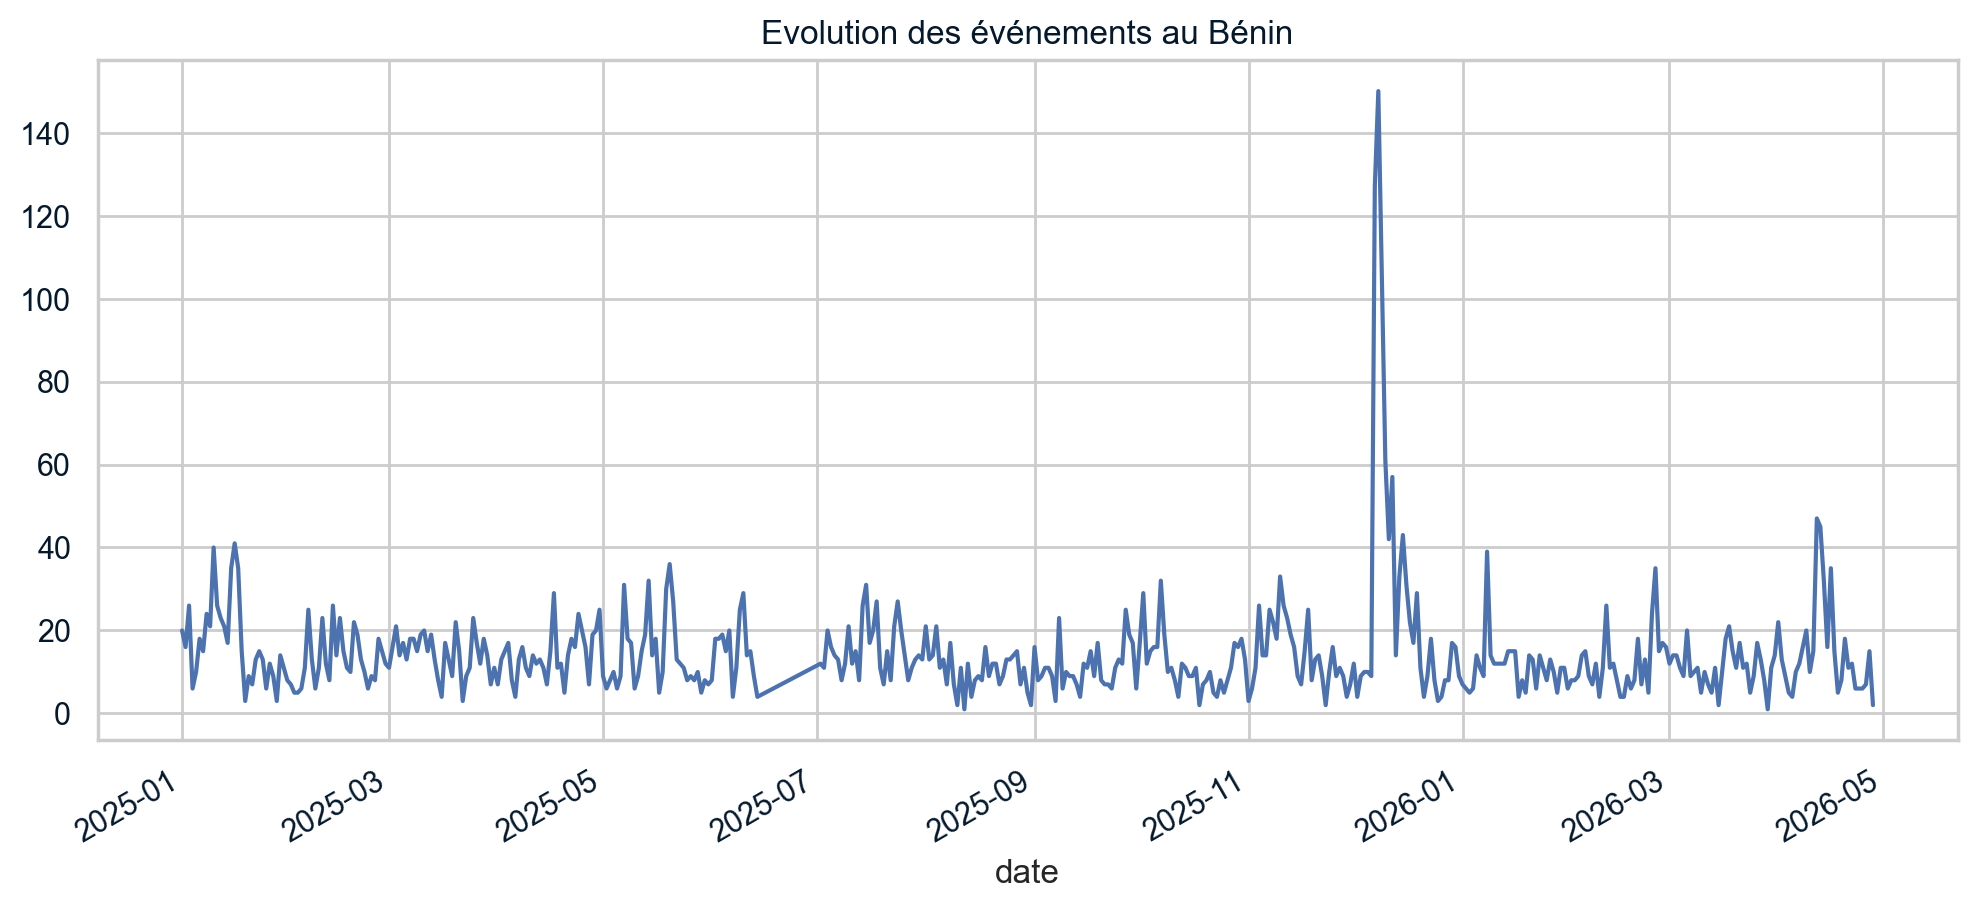

In [19]:
plt.figure(figsize=(12,5))
df_clean.groupby('date').size().plot()
plt.title("Evolution des événements au Bénin")
plt.show()

### Observation

Ce graphique présente le nombre d’événements enregistrés par jour au Bénin.

On observe une variation importante dans le volume des événements au cours du temps, avec un pic notable autour de décembre 2025 à janvier 2026. Et un second pic moyen autour de avril 2026.

Ces pics peuvent être mis en relation avec des événements politiques majeurs, notamment une tentative de coup d’État signalée durant la période de decembre 2025 et les élections presidentielles d'avril 2026. Cela illustre que ces variations reflètent une intensification de la couverture médiatique plutôt qu’une augmentation réelle des événements.


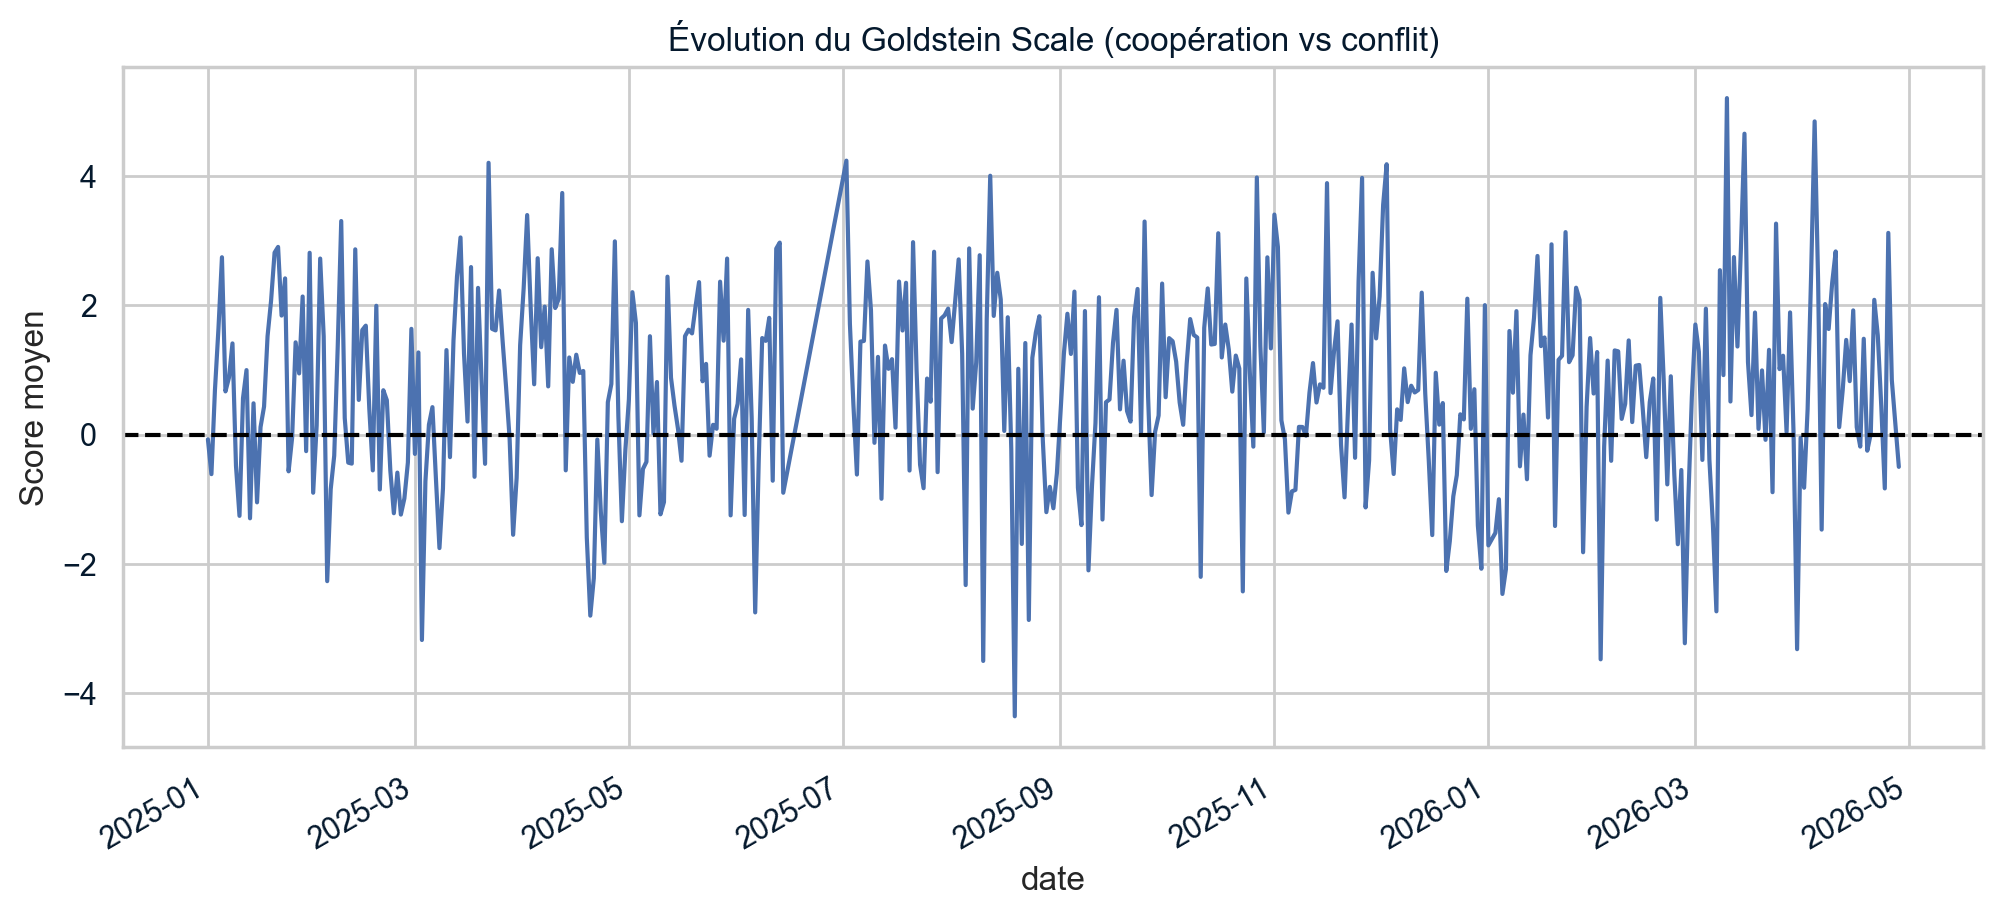

In [20]:
goldstein_time = df_clean.groupby('date')['GoldsteinScale'].mean()

plt.figure(figsize=(12,5))
goldstein_time.plot()

plt.axhline(0, color='black', linestyle='--')

plt.title("Évolution du Goldstein Scale (coopération vs conflit)")
plt.ylabel("Score moyen")
plt.show()

### Distribution des types d’événements


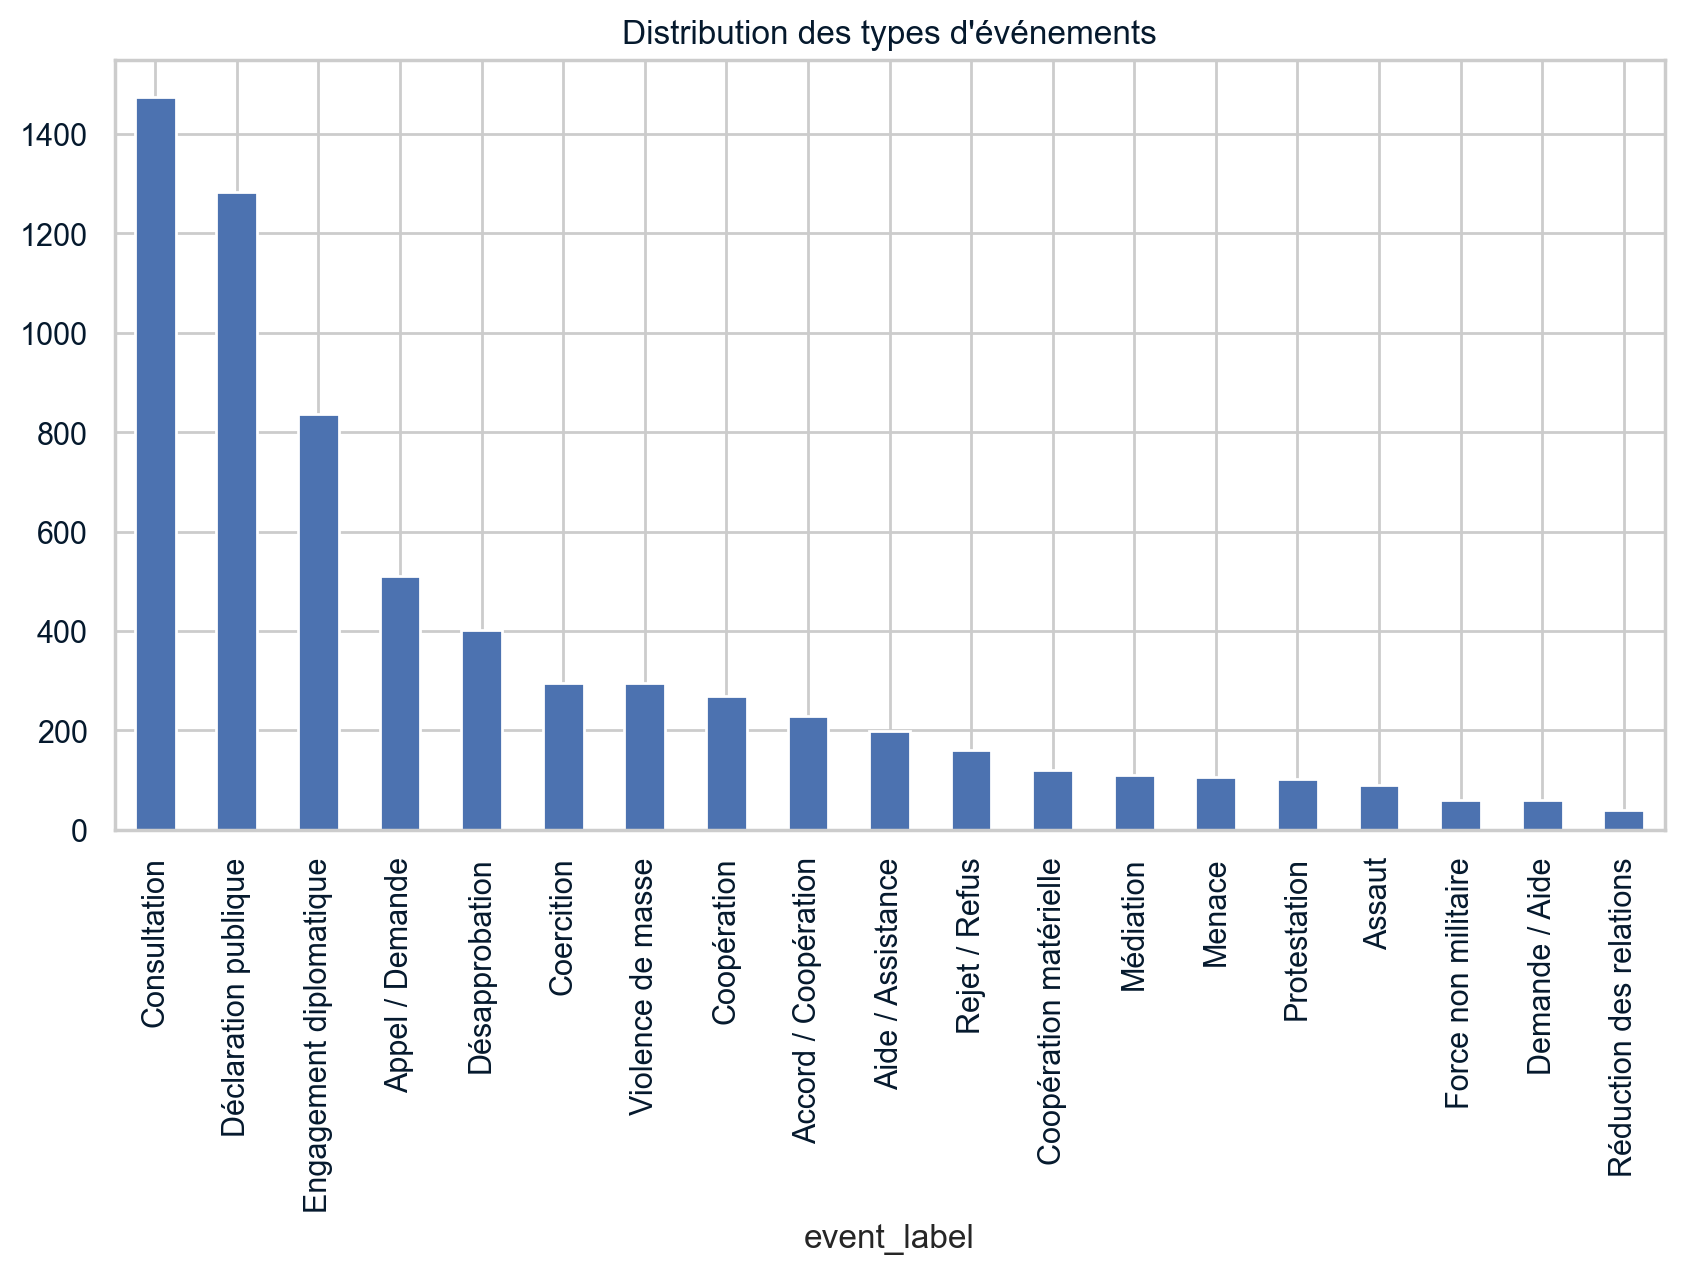

In [21]:
plt.figure(figsize=(10,5))
df_clean['event_label'].value_counts().plot(kind='bar')
plt.title("Distribution des types d'événements")
plt.show()

### Observations

L’analyse montre une dominance des événements de type consultation, suivis des types déclaration publique et engagement diplomatique.

Cela indique que les interactions observées au Bénin sont principalement de nature institutionnelle et diplomatique ainsi qu’à des interactions politiques (déclarations, communications).

La présence significative d’événements de coopération suggère toutefois un équilibre partiel dans les relations observées.


### Analyse du sentiment médiatique

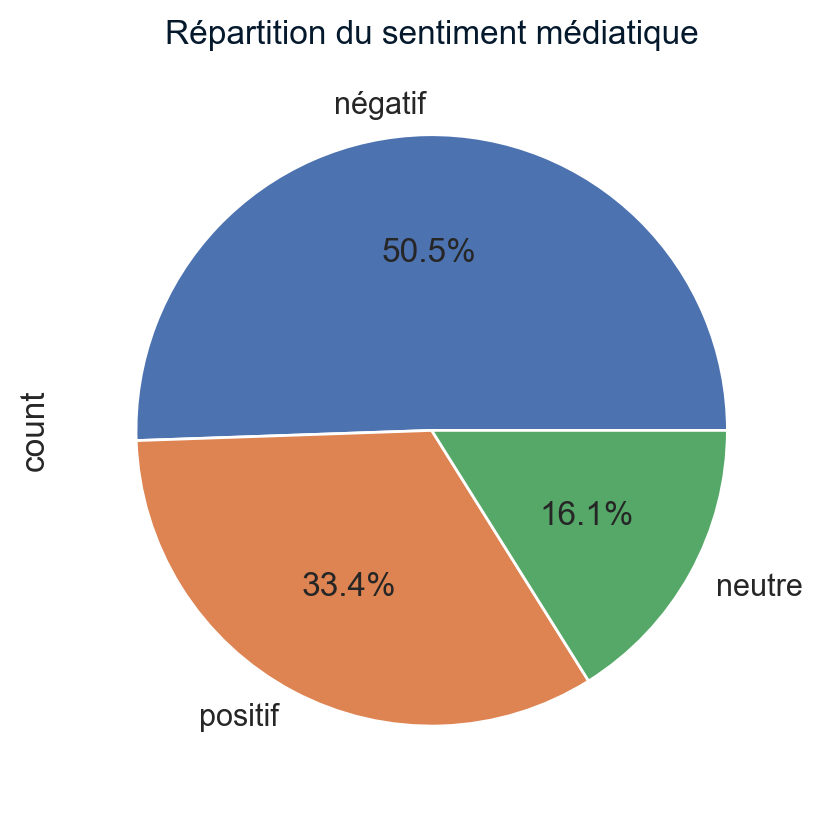

In [22]:
df_clean['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Répartition du sentiment médiatique")
plt.show()

### Observation

La majorité des événements sont associés à un sentiment négatif (50.5%), contre 33.4% de sentiment positif.

Cette dominance du négatif reflète une tendance des médias à couvrir davantage les crises, conflits et événements problématiques.

Il est donc important de considérer un biais médiatique dans l’interprétation de ces résultats.


### Intensité de la couverture médiatique en fonction du type d'évenement

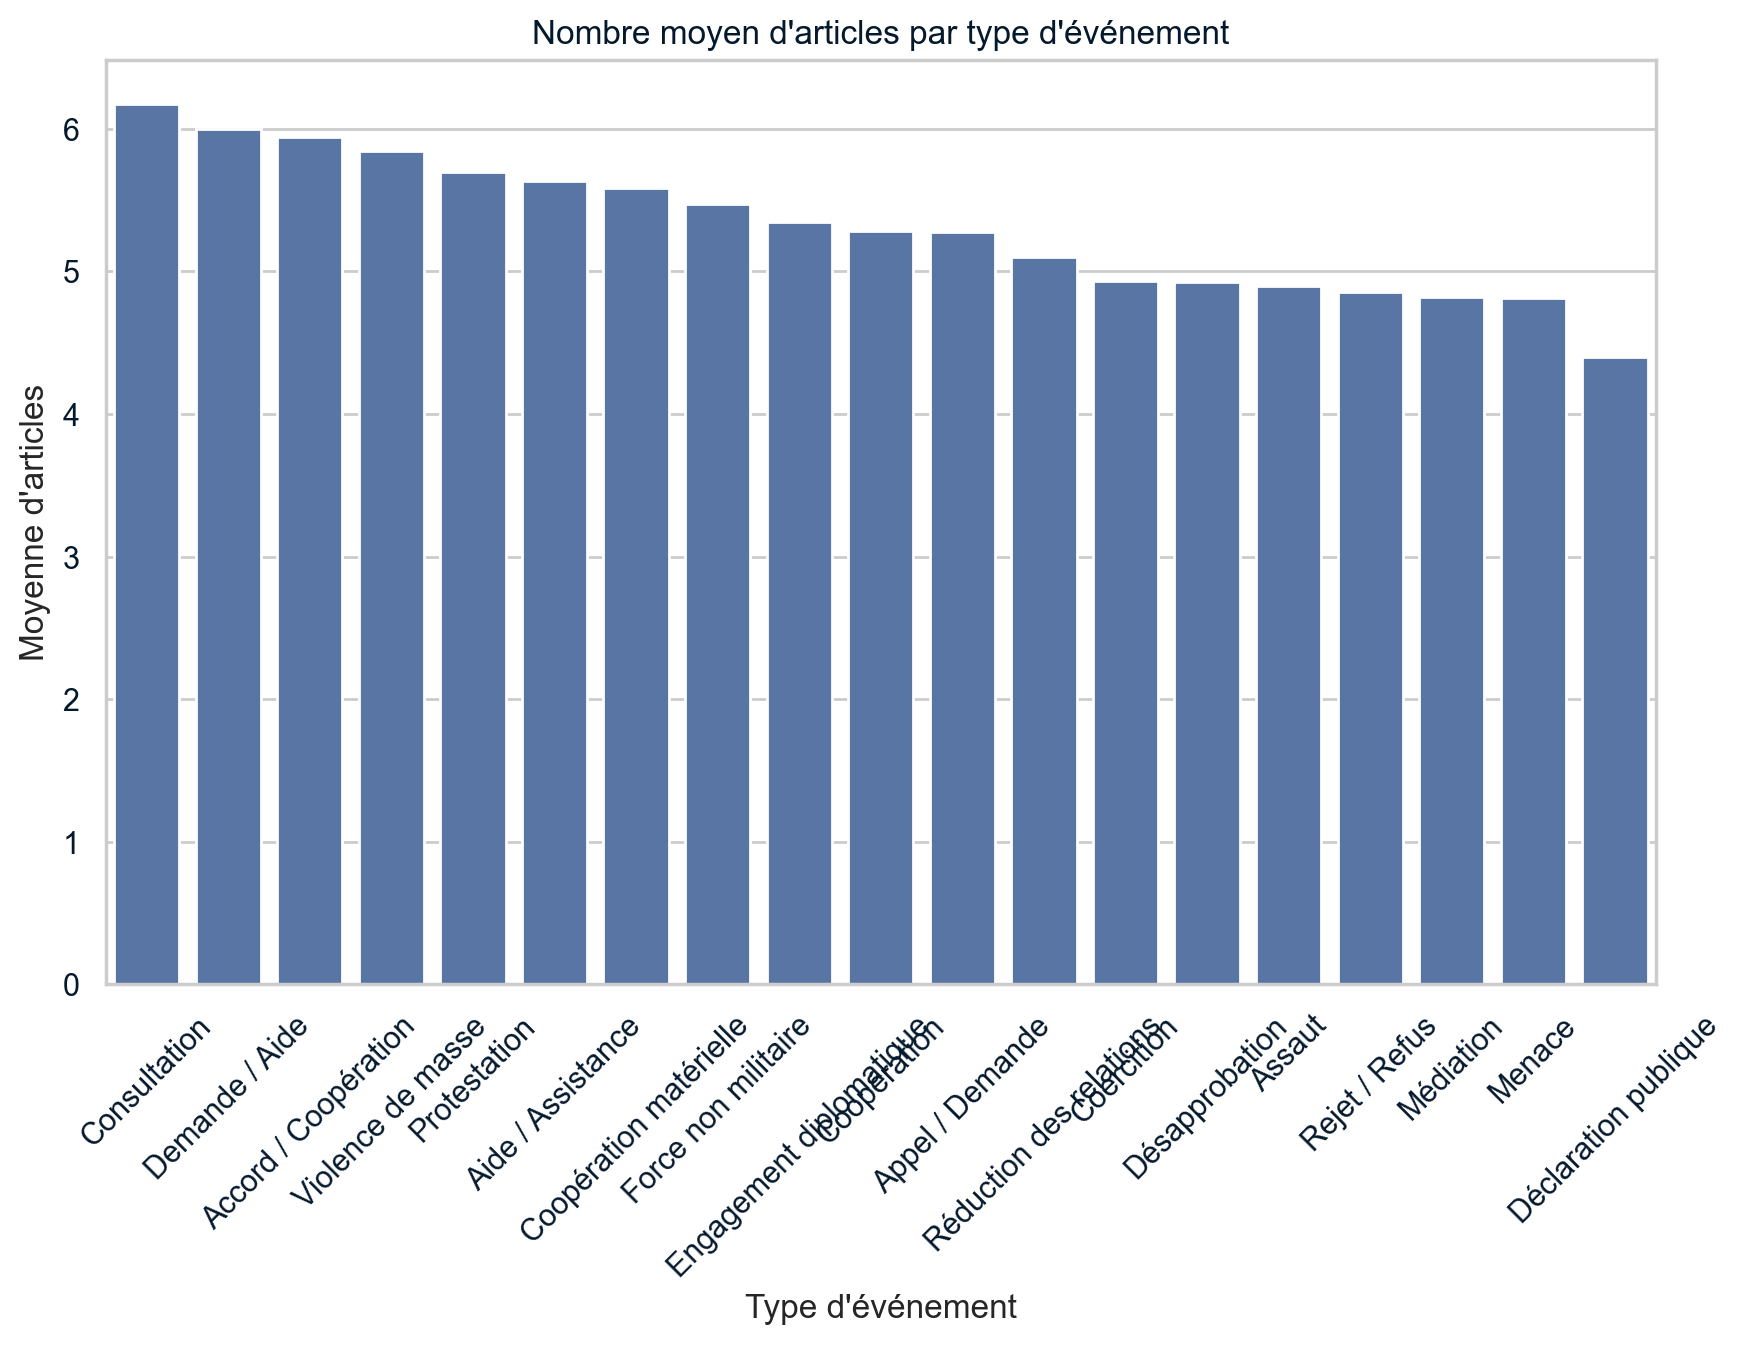

In [32]:
event_media = df_clean.groupby('event_label')['NumArticles'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=event_media.index, y=event_media.values)
plt.xticks(rotation=45)
plt.title("Nombre moyen d'articles par type d'événement")
plt.xlabel("Type d'événement")
plt.ylabel("Moyenne d'articles")
plt.show()

### Observation

L’analyse met en évidence que la couverture médiatique des événements n’est pas uniforme et dépend fortement de leur nature.

Les événements liés à la consultation, à la demande d’aide et à la coopération présentent en moyenne un nombre d’articles plus élevé, ce qui suggère qu’ils bénéficient d’une attention médiatique plus importante par occurrence. Cette forte visibilité peut s’expliquer par leur caractère institutionnel et leur lien avec des acteurs officiels, souvent relayés par plusieurs sources d’information.


### Répartition géographique et intensité des événements

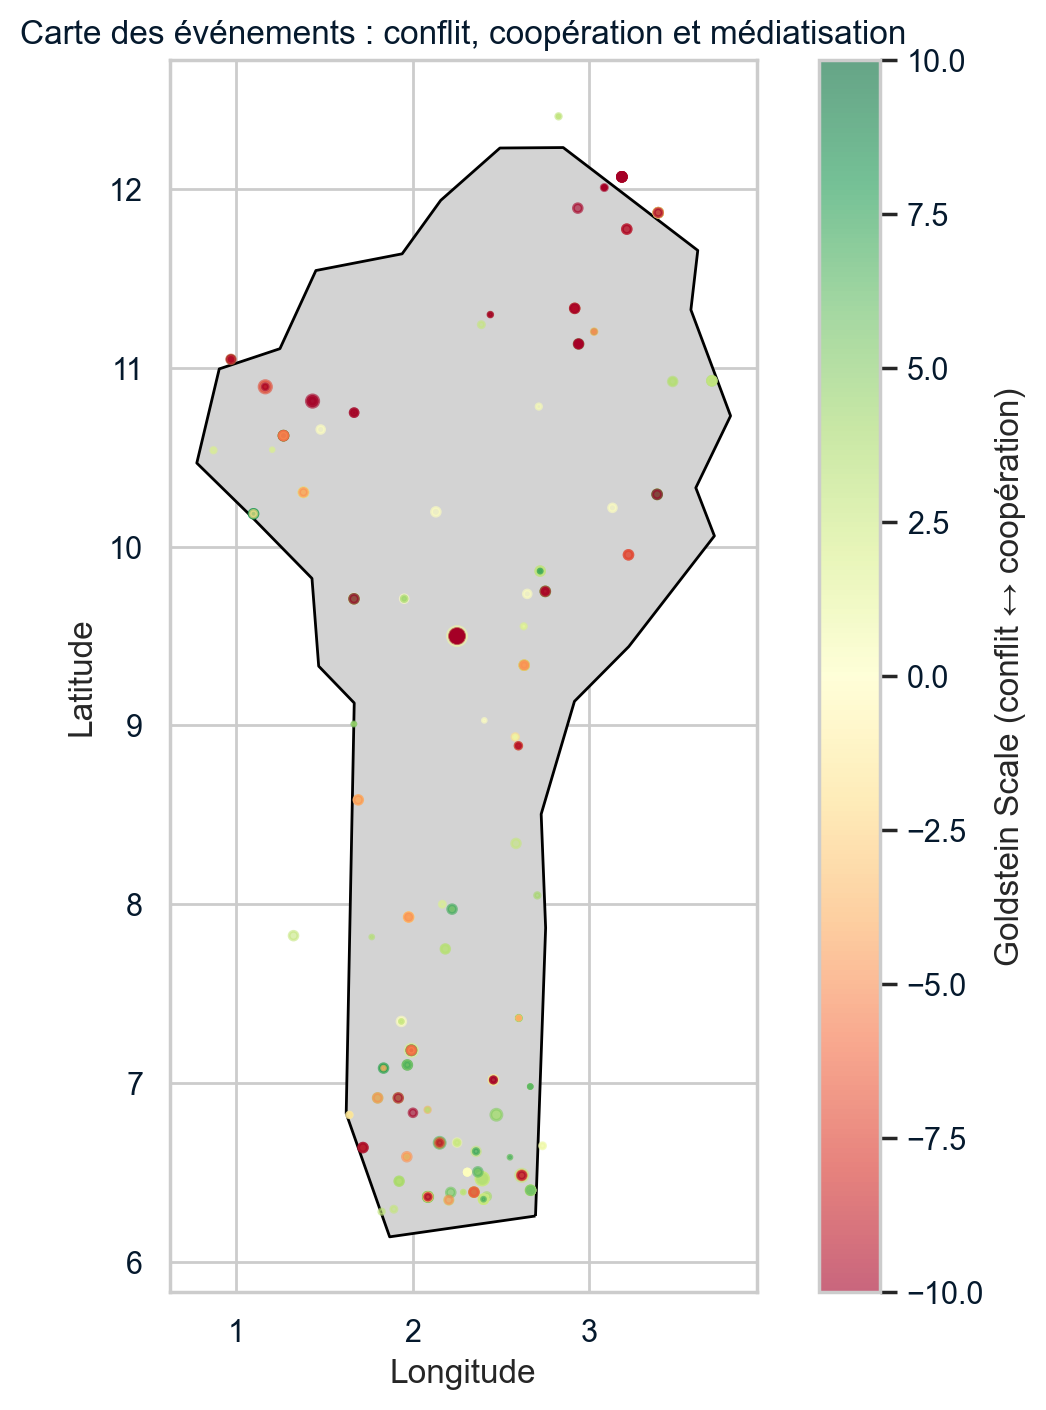

In [24]:
# Charger carte
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Filtrer Bénin
benin = world[world['NAME'] == 'Benin']

# GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean['ActionGeo_Long'], df_clean['ActionGeo_Lat']),
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(8,8))

# Carte de fond
benin.plot(ax=ax, color='lightgrey', edgecolor='black')

# Scatter (IMPORTANT : matplotlib, pas geopandas)
scatter = ax.scatter(
    df_clean['ActionGeo_Long'],
    df_clean['ActionGeo_Lat'],
    c=df_clean['GoldsteinScale'],
    s=df_clean['NumArticles'],  # taille des points
    cmap='RdYlGn',
    alpha=0.6
)

# Barre de couleur
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Goldstein Scale (conflit ↔ coopération)")

plt.title("Carte des événements : conflit, coopération et médiatisation")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Observations

Cette carte met en évidence la distribution spatiale des événements au Bénin, tout en intégrant leur nature (conflit ou coopération) et leur intensité médiatique.

Les zones avec des couleurs rouges indiquent des événements conflictuels, tandis que les zones vertes traduisent des interactions coopératives.

La taille des points reflète l’importance médiatique des événements.

On observe une concentration des événements dans les zones du sud, notamment autour de Cotonou, ainsi que des foyers potentiels de tension dans certaines régions en allant vers le nord.


### Relations internationales

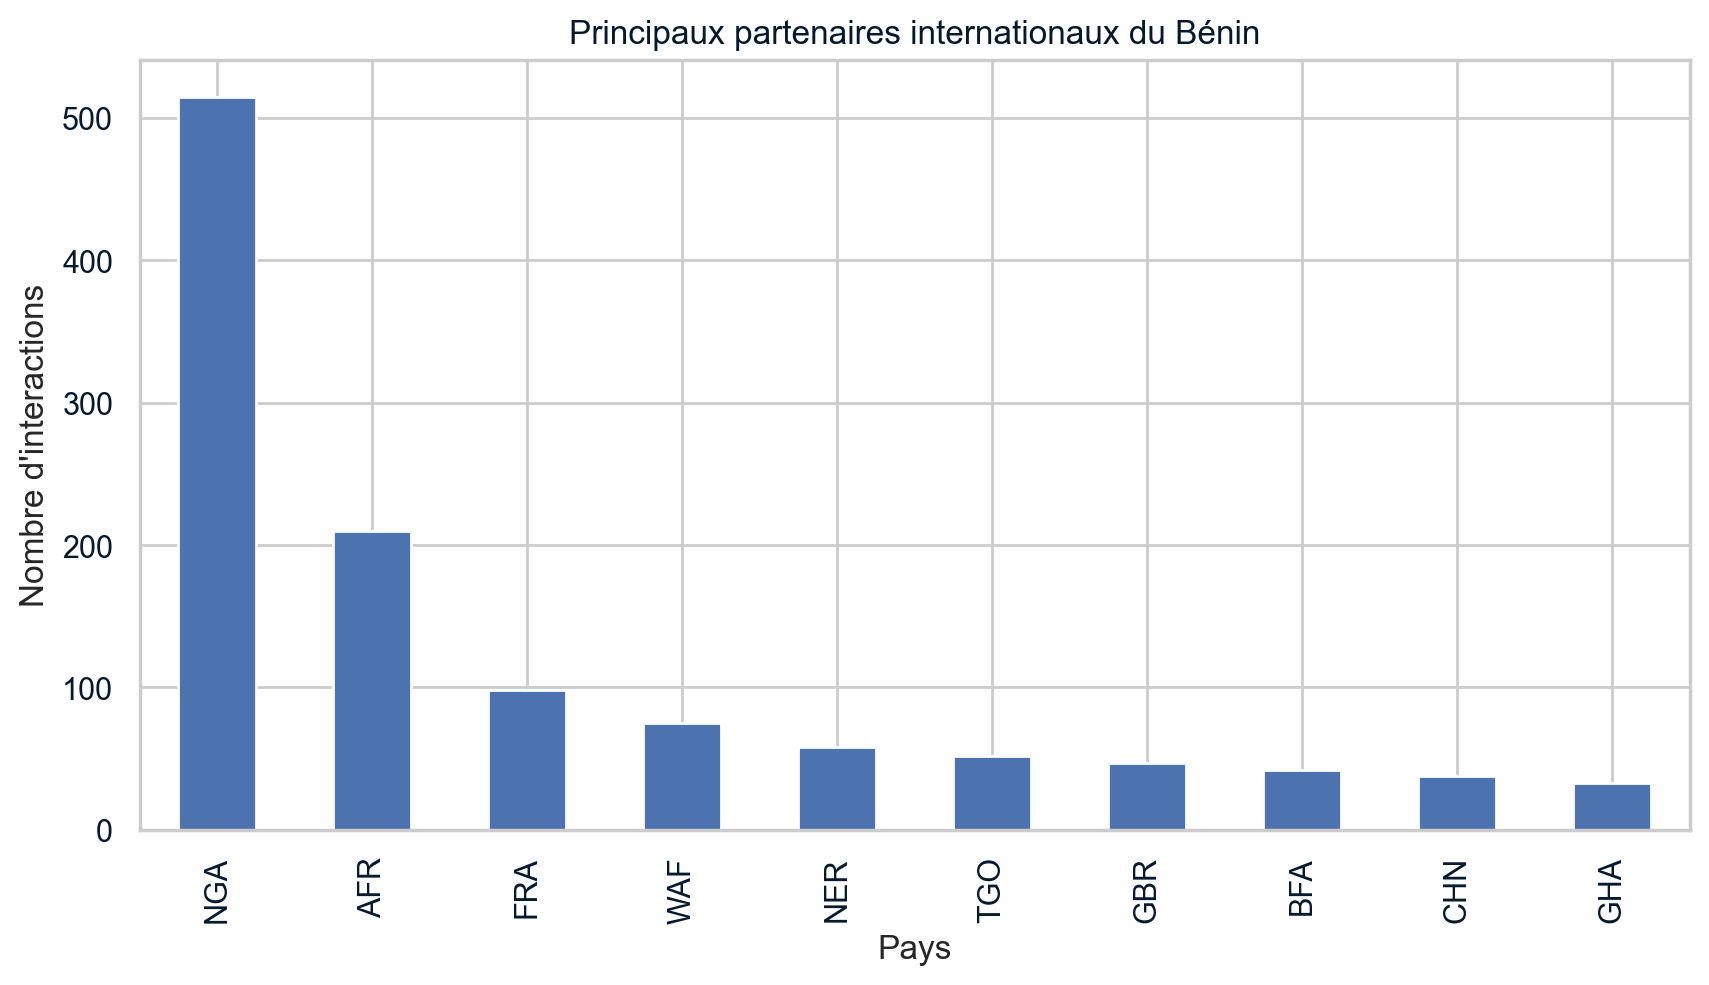

In [25]:
intl = df_clean[~df_clean['Actor2CountryCode'].isin(['Inconnu', 'BEN'])]

top_countries = intl['Actor2CountryCode'].value_counts().head(10)

top_countries.plot(kind='bar', figsize=(10,5))

plt.title("Principaux partenaires internationaux du Bénin")
plt.xlabel("Pays")
plt.ylabel("Nombre d'interactions")
plt.show()

### Observations

L’analyse des interactions internationales met en évidence une forte concentration des relations du Bénin avec le Nigeria, ainsi qu’avec plusieurs pays africains et la France.

Dans l’ensemble, ces résultats montrent que les relations internationales du Bénin sont structurées autour de trois axes principaux : une forte dépendance régionale, une intégration africaine active, et des liens durables avec des partenaires internationaux historiques.

Toutefois, ces observations doivent être nuancées car les données GDELT reflètent avant tout la couverture médiatique.


### Insights clés

* L’activité événementielle présente des pics significatifs, souvent associés à des crises politiques ou sécuritaires.
* Le paysage médiatique est dominé par des événements à tonalité négative, reflétant un biais structurel des médias.
* La majorité des événements bénéficie d’une faible couverture médiatique, avec quelques cas fortement médiatisés.
* Les dynamiques observées montrent un mélange de tensions et de coopération, avec des variations temporelles importantes.
* Les interactions internationales jouent un rôle clé dans la visibilité du Bénin sur la scène médiatique mondiale.


### Modélisation prédictive

#### 1. Objectif du modèle

L’objectif de cette phase est de construire un modèle de machine learning capable de prédire l’impact potentiel d’un événement. Plus précisément, il s’agit d’anticiper si un événement sera fortement médiatisé, en se basant sur ses caractéristiques (type d’événement, intensité, contexte international, etc.).

La variable cible retenue est `is_high_media`, une variable binaire indiquant si un événement est fortement médiatisé (nombre d’articles supérieur à la médiane).

---

#### 2. Sélection des variables explicatives

Les variables utilisées pour la modélisation sont les suivantes :

* `GoldsteinScale` : mesure l’intensité de l’événement (conflit ou coopération)
* `EventRootCode` : catégorie générale de l’événement
* `is_international` : indique si l’événement implique un acteur étranger

Ces variables ont été choisies pour leur pertinence analytique et leur capacité à capturer des dimensions clés de l’événement (nature, intensité, portée).

---

#### 3. Préparation des données

Avant l’entraînement du modèle, plusieurs étapes de préparation ont été réalisées :

* encodage de la variable catégorielle `EventRootCode`
* division du dataset en jeu d’entraînement (80%) et de test (20%)

Ces étapes garantissent la qualité et la validité de l’apprentissage.

---

#### 4. Modèles utilisés

* **Random Forest** : modèle d’ensemble basé sur plusieurs arbres de décision, capable de capturer des relations complexes et non linéaires

---

#### 5. Évaluation des performances

Les modèles ont été évalués à l’aide de plusieurs métriques :

* **Accuracy** : proportion de prédictions correctes
* **Precision** : capacité à éviter les faux positifs
* **Recall** : capacité à détecter les événements fortement médiatisés
* **F1-score** : compromis entre précision et rappel

Une attention particulière est portée au recall, car manquer un événement important (faux négatif) peut être critique dans un contexte journalistique ou décisionnel.

---

#### 6. Résultats et comparaison



---

#### 7. Interprétation des variables

L’analyse des variables montre que :

* les événements à forte intensité (GoldsteinScale extrême) sont plus susceptibles d’être médiatisés
* les événements impliquant des acteurs internationaux attirent davantage l’attention médiatique
* certains types d’événements (conflits, protestations) sont plus visibles que d’autres

Ces résultats confirment des intuitions issues de l’analyse exploratoire.

---

#### Conclusion

Cette modélisation permet de mieux comprendre les facteurs qui influencent la médiatisation des événements au Bénin. Elle constitue une première étape vers des outils d’aide à la décision pour les journalistes, les chercheurs et les institutions publiques.


In [26]:
features = ['GoldsteinScale','EventRootCode','is_international']

df_ml = df_clean[features + ['is_high_media']].dropna()

# Encoder EventRootCode
le = LabelEncoder()
df_ml['EventRootCode'] = le.fit_transform(df_ml['EventRootCode'])

X = df_ml[features]
y = df_ml['is_high_media']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [27]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.83      0.71       766
           1       0.59      0.34      0.43       564

    accuracy                           0.62      1330
   macro avg       0.61      0.58      0.57      1330
weighted avg       0.61      0.62      0.59      1330



In [28]:
importances = model.feature_importances_
for f, imp in zip(features, importances):
    print(f, imp)

GoldsteinScale 0.5866049881711126
EventRootCode 0.36953677239905924
is_international 0.04385823942982806


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Prédictions
y_pred_rf = model.predict(X_test)

# Métriques
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.618796992481203
Precision: 0.5882352941176471
Recall: 0.33687943262411346
F1-score: 0.42841037204058624


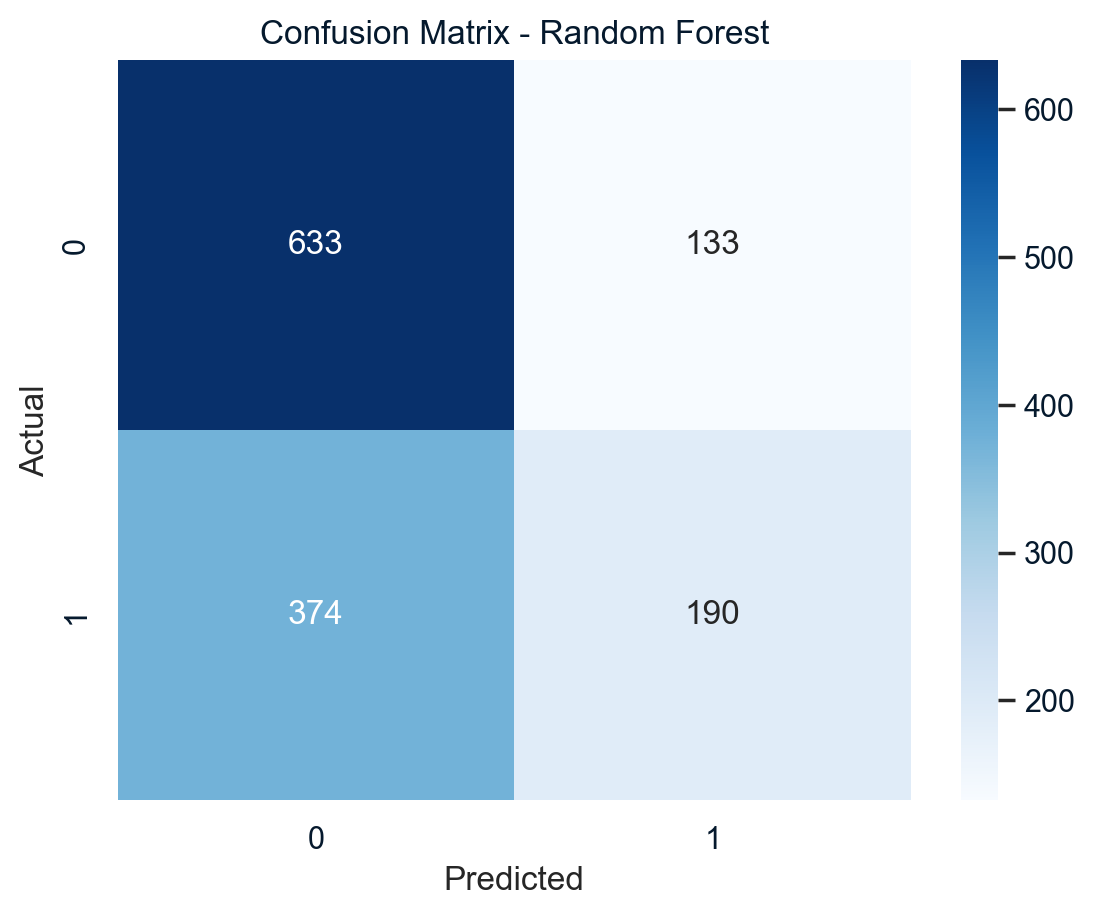

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()